# ASRQuant 1.2.0 — Official Quickstart Notebook

**Alpha Stochastic Research**

This notebook provides a reproducible introduction to the public **ASRQuant 1.2.0** API. It uses deterministic synthetic data so that the examples do not depend on external providers, credentials, network availability, or revised market-data vintages.

The notebook follows a complete quantitative-research path:

**data → validation → portfolio construction → backtesting → derivatives → rates → alpha → risk → microstructure → hypothesis discovery → regression → walk-forward machine learning**

Each section contains four elements:

1. the quantitative idea;
2. the relevant mathematical definition;
3. the ASRQuant implementation;
4. a compact interpretation of the output.

> **Research-use notice.** ASRQuant is research software. The examples below are educational and reproducible demonstrations; they are not investment recommendations and do not authorize live capital deployment.

## 0. Installation and version check

Install ASRQuant from the repository root with:

```bash
python -m pip install -e .
```

For the published release, use:

```bash
python -m pip install "asrquant==1.2.0"
```

The first code cell verifies that the notebook is running against the intended release. Reproducible research starts by recording the exact software version used to generate the results.

In [1]:
import numpy as np
import pandas as pd
import asrquant as asr

print("ASRQuant version:", asr.__version__)
assert asr.__version__ == "1.2.0", "This notebook is written for ASRQuant 1.2.0"

ASRQuant version: 1.2.0


## 1. Create a deterministic market panel

We first build a synthetic multi-asset return panel with one common factor and asset-specific noise. This creates cross-sectional dependence without relying on external market data.

For asset `i` at time `t`, the simulated return follows:

$$
r_{i,t} = \beta_i f_t + \varepsilon_{i,t}
$$

where `f_t` is the common factor, `β_i` controls the asset's exposure to that factor, and `ε_{i,t}` is idiosyncratic noise.

Prices are reconstructed from returns by compounding:

$$
P_{i,t} = P_{i,0}\prod_{s=1}^{t}(1+r_{i,s})
$$

A fixed random seed makes the entire example reproducible.

In [2]:
rng = np.random.default_rng(42)
index = pd.date_range("2024-01-02", periods=360, freq="B")
assets = ["ALPHA", "BETA", "GAMMA", "DELTA", "EPSILON", "ZETA"]

factor = rng.normal(0.00025, 0.0075, len(index))
betas = np.array([0.75, 0.95, 1.10, 1.25, 1.40, 0.65])
idio = rng.normal(0.0, 0.006, size=(len(index), len(assets)))

returns = pd.DataFrame(
    factor[:, None] * betas[None, :] + idio,
    index=index,
    columns=assets,
)
prices = 100.0 * (1.0 + returns).cumprod()

prices.tail()

,ALPHA,BETA,GAMMA,DELTA,EPSILON,ZETA
2025-05-13,83.695689,94.514826,102.244363,107.316349,94.223594,88.675601
2025-05-14,83.760428,93.451756,102.133977,108.378916,94.801154,88.923776
2025-05-15,84.410425,93.925595,103.136083,109.285344,95.968991,89.246854
2025-05-16,84.474808,93.197052,102.057654,109.554103,95.257103,89.316732
2025-05-19,84.483263,92.793254,101.968230,110.380731,95.460228,88.349830


## 2. Data quality and input validation

Before modelling, a research workflow should verify the structure of the data rather than silently repairing it. `asr.data.validate` inspects the time-series contract and reports potential issues while preserving the original input.

For a price series, the corresponding simple return is defined as:

$$
r_t = \frac{P_t}{P_{t-1}} - 1
$$

Typical checks include missing observations, non-finite values, duplicate timestamps, ordering, and basic shape consistency. The objective is to make data problems explicit before they propagate into models or backtests.

In [3]:
quality = asr.data.validate(prices)
quality.summary

rows                                    360
columns                                   6
start                   2024-01-02 00:00:00
end                     2025-05-19 00:00:00
missing_values                            0
missing_fraction                        0.0
duplicate_timestamps                      0
monotonic_index                        True
median_spacing              1 days 00:00:00
maximum_gap                 3 days 00:00:00
constant_columns                          0
infinite_values                           0
non_numeric_values                        0
Name: value, dtype: object

## 3. Portfolio construction

The canonical portfolio entry point is `asr.portfolio.optimize`. In this example we use **minimum variance** portfolio construction.

Let `w` denote the vector of portfolio weights and `Σ` the estimated covariance matrix of asset returns. The minimum-variance problem is:

$$
\min_{w}\; w^{\top}\Sigma w
$$

subject to the full-investment constraint:

$$
\mathbf{1}^{\top}w = 1
$$

ASRQuant 1.2.0 also exposes other portfolio methods through the same public interface, including maximum Sharpe, equal risk contribution, maximum diversification, and hierarchical risk parity.

In [4]:
portfolio = asr.portfolio.optimize(
    returns,
    method="minimum_variance",
)

print("Summary")
display(portfolio.summary)
print("Weights")
display(portfolio.weights.to_frame())

Summary


method             minimum_variance
success                        True
expected_return           -0.079894
volatility                 0.106827
sharpe                    -0.747886
gross_exposure                  1.0
net_exposure                    1.0
n_assets                          6
dtype: object

Weights


,weight
ALPHA,3.736153e-01
BETA,1.385744e-01
GAMMA,0.000000e+00
DELTA,3.189563e-02
EPSILON,1.422647e-17
ZETA,4.559147e-01


## 4. Auditable backtesting

Portfolio construction and backtesting are separate research stages. The optimizer determines target exposures; the backtest determines how those exposures would have evolved through time under an explicit chronology.

Ignoring costs for a moment, one-period portfolio return is:

$$
r_{p,t} = w_{t-1}^{\top}r_t
$$

and portfolio wealth evolves as:

$$
V_t = V_{t-1}(1+r_{p,t}-c_t)
$$

where `c_t` represents transaction costs or other execution frictions when modelled.

In this tutorial the optimized weights are held constant only to demonstrate the canonical backtest API. A real strategy should define signal timing, rebalance timing, execution delays, costs, and all other implementation assumptions explicitly.

In [5]:
target_weights = pd.DataFrame(
    np.tile(portfolio.weights.to_numpy(), (len(prices), 1)),
    index=prices.index,
    columns=prices.columns,
)

backtest = asr.backtesting.run(prices, target_weights)
backtest.summary

Total Return             -1.201430e-01
CAGR                     -8.570057e-02
Annual Volatility         1.067071e-01
Sharpe                   -7.862724e-01
Sortino                  -1.068333e+00
Max Drawdown             -1.849418e-01
Calmar                   -4.633921e-01
Omega                     8.845306e-01
VaR 95%                   1.127776e-02
ES 95%                    1.440111e-02
Ulcer Index               1.103412e-01
CDaR 95%                  1.777714e-01
Max Drawdown Duration     3.560000e+02
Kelly Fraction           -7.368510e+00
Gaussian VaR 95%          1.138951e-02
Cornish-Fisher VaR 95%    1.145963e-02
Tail Ratio                8.993411e-01
Hit Rate                  4.707521e-01
Profit Factor             8.845306e-01
Skew                     -3.076802e-02
Excess Kurtosis          -8.443986e-02
PSR                       3.847138e-40
Average Turnover          2.777778e-03
Annual Turnover           7.000000e-01
Name: value, dtype: float64

### Backtest visualization

`BacktestResult.plot("dashboard")` produces the standard diagnostic view from the result object.

A common cumulative-return representation is:

$$
V_t = V_0\prod_{s=1}^{t}(1+r_{p,s})
$$

The chart below is a tutorial output, not a claim of strategy performance. In empirical work, interpretation should be accompanied by robustness checks, turnover analysis, drawdowns, benchmark comparisons, and out-of-sample evidence.

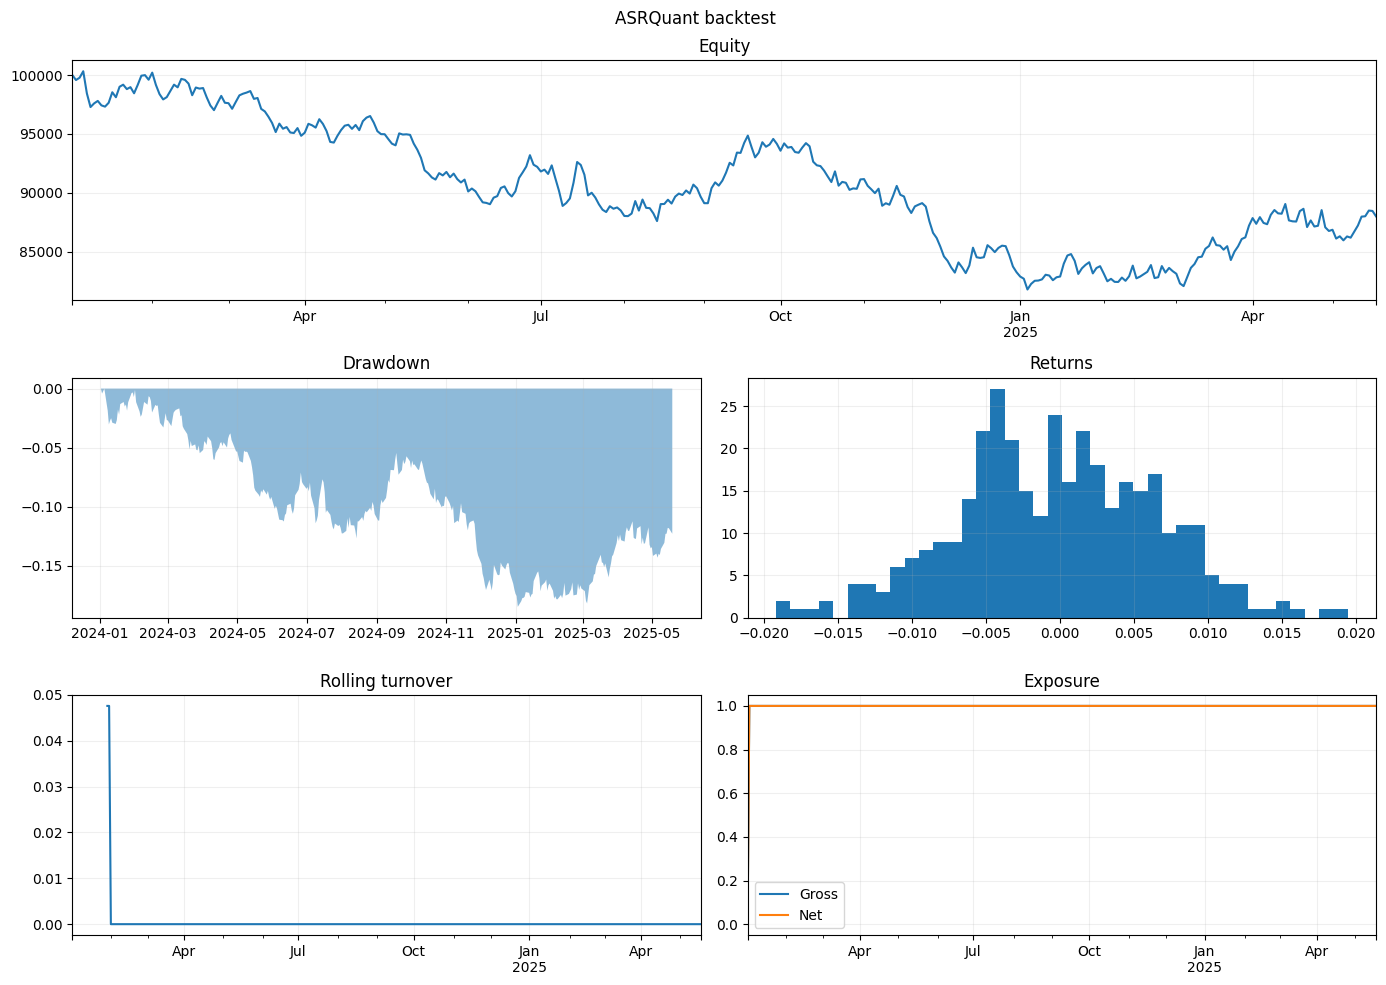

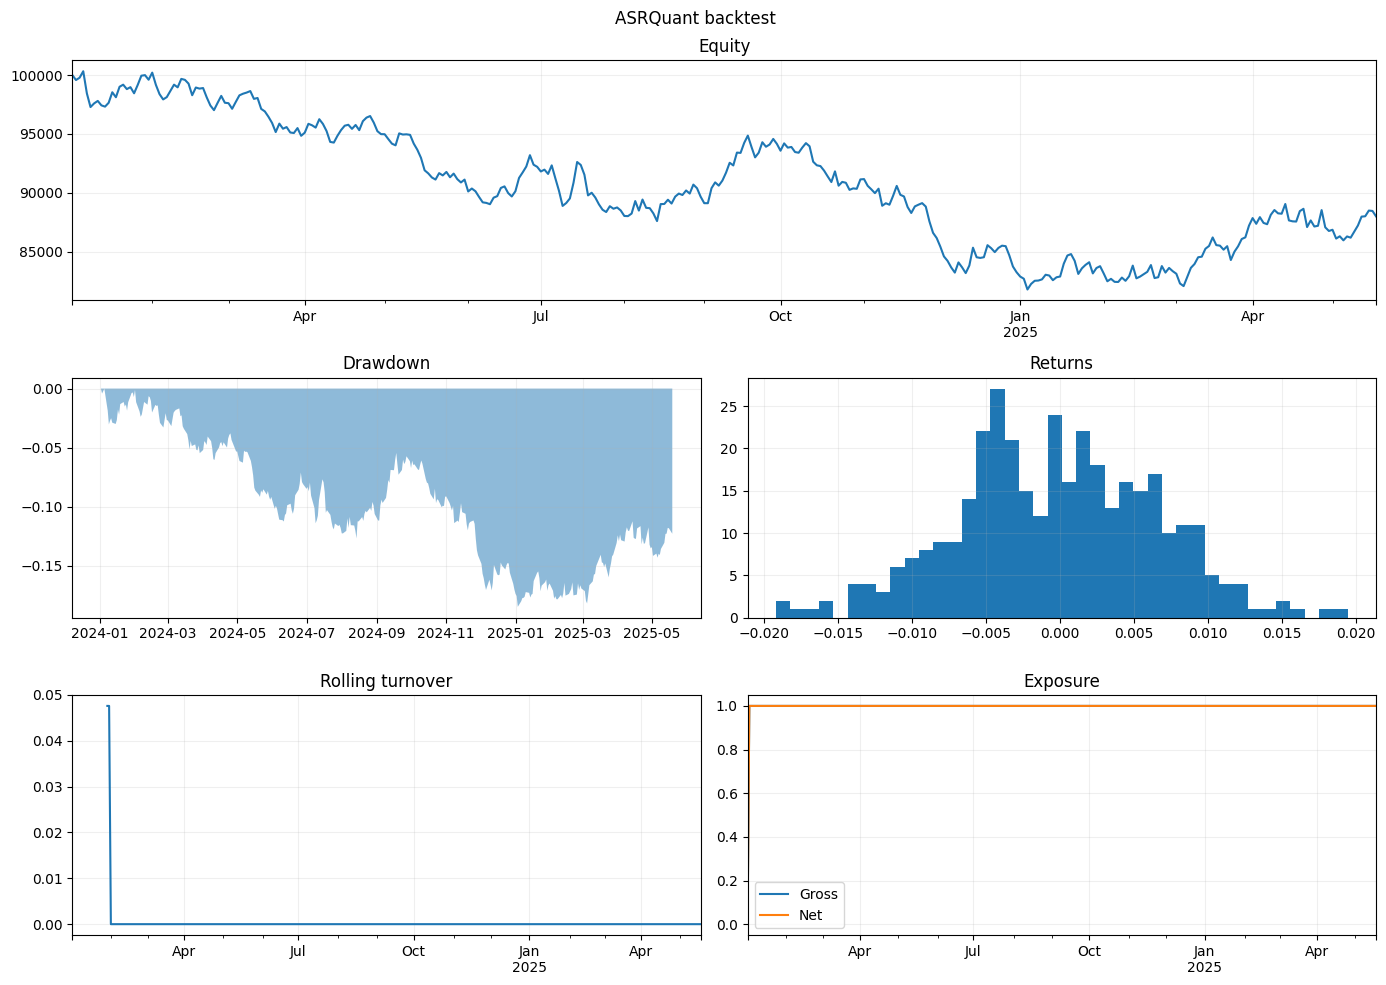

In [6]:
backtest.plot("dashboard")

## 5. Option pricing

The canonical derivatives verb is `asr.options.price`. We illustrate it with a European option under the Black–Scholes model.

For a European call option, the price is:

$$
C = S_0N(d_1) - Ke^{-rT}N(d_2)
$$

with:

$$
d_1 = \frac{\ln(S_0/K) + (r + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

where `S_0` is spot, `K` is strike, `r` is the continuously compounded risk-free rate, `σ` is volatility, `T` is time to maturity, and `N` is the standard normal cumulative distribution function.

The model name and parameters remain explicit in the ASRQuant call so that the pricing assumption is reviewable.

In [7]:
option = asr.options.price(
    "black_scholes",
    spot=100,
    strike=100,
    maturity=1.0,
    rate=0.03,
    volatility=0.20,
)
option.summary

price         9.413403
model    black_scholes
delta         0.598706
gamma         0.019333
vega         38.666812
theta        -5.380398
rho          50.457229
dtype: object

## 6. Yield curves, discounting and swaps

The rates stack exposes a high-level `RateQuantLab` together with lower-level curve and instrument functions.

For a continuously compounded zero rate `z(T)`, the discount factor is:

$$
P(0,T) = e^{-z(T)T}
$$

For payment dates `T_1, ..., T_n` with accrual fractions `Δ_i`, the par fixed rate of a standard interest-rate swap is:

$$
K_{\mathrm{par}} = \frac{P(0,T_0)-P(0,T_n)}{\sum_{i=1}^{n}\Delta_i P(0,T_i)}
$$

For a spot-starting swap with `T_0 = 0` and `P(0,0)=1`, this becomes:

$$
K_{\mathrm{par}} = \frac{1-P(0,T_n)}{\sum_{i=1}^{n}\Delta_i P(0,T_i)}
$$

The cells below construct a zero curve, inspect its diagnostics, compute a five-year par swap rate, and value a payer swap struck 10 basis points above par.

In [8]:
maturities = np.array([0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30.0])
zero_rates = np.array([0.0200, 0.0205, 0.0210, 0.0220, 0.0230,
                       0.0250, 0.0260, 0.0270, 0.0285, 0.0290])

rates_lab = asr.RateQuantLab.from_zero_rates(maturities, zero_rates)
curve_report = asr.rates.analyze(rates_lab.curve)
curve_report.summary

nodes                            10
min_maturity                   0.25
max_maturity                   30.0
min_zero_rate                  0.02
max_zero_rate                 0.029
positive_discounts             True
time_zero_is_one               True
discounts_nonincreasing        True
minimum_discount           0.418952
minimum_simple_forward      0.02005
maximum_simple_forward     0.034986
dtype: object

In [9]:
par_5y = rates_lab.par_swap(0, 5, frequency=2)
swap_pv = rates_lab.swap(
    0,
    5,
    par_5y + 0.001,
    notional=1_000_000,
    frequency=2,
)

pd.Series({
    "5Y par swap rate": par_5y,
    "PV of payer swap at par + 10bp": swap_pv,
})

5Y par swap rate                     0.025060
PV of payer swap at par + 10bp   -4688.866847
dtype: float64

## 7. Cross-sectional alpha diagnostics

We use a 20-business-day momentum score and lag it by one day so that the signal available at time `t` does not use information from the future.

A simple momentum signal is:

$$
s_{i,t} = \frac{P_{i,t}}{P_{i,t-20}} - 1
$$

After cross-sectional standardization, one useful diagnostic is the information coefficient between the signal and subsequent returns:

$$
IC_t = \operatorname{Corr}(s_{i,t}, r_{i,t\rightarrow t+h})
$$

`asr.alpha.analyze_signal` evaluates the signal using cross-sectional IC, quantile behaviour, long-short returns, turnover, and related diagnostics. Statistical association alone should not be interpreted as economic or scientific validity.

In [10]:
raw_signal = prices.pct_change(20, fill_method=None).shift(1)
signal = asr.alpha.cross_sectional_zscore(raw_signal)
forward_5d = asr.alpha.forward_returns(prices, 5)[5]

alpha_report = asr.alpha.analyze_signal(
    signal,
    forward_5d,
    quantiles=3,
    min_assets=5,
)
alpha_report.summary

mean_ic                    -0.011292
ic_ir                      -0.027401
ic_positive_rate            0.523952
mean_long_short_return     -0.001070
long_short_t_stat          -1.583633
mean_turnover               0.151862
observations              334.000000
Name: value, dtype: float64

## 8. Portfolio risk

A signal becomes economically meaningful only after its exposures and risk consequences are understood. Here we evaluate the latest finite signal weights against a trailing return window.

Portfolio volatility is:

$$
\sigma_p = \sqrt{w^{\top}\Sigma w}
$$

For a loss variable `L` and confidence level `α`, Value at Risk is the corresponding loss quantile:

$$
\operatorname{VaR}_{\alpha}(L) = \inf\{\ell : \Pr(L\leq \ell)\geq \alpha\}
$$

Expected Shortfall measures the average loss beyond that threshold:

$$
\operatorname{ES}_{\alpha}(L) = \mathbb{E}[L\mid L\geq \operatorname{VaR}_{\alpha}(L)]
$$

The ASRQuant risk report combines portfolio-level measures with contribution diagnostics so that aggregate risk can be traced back to exposures.

In [11]:
latest_signal_weights = alpha_report.weights.dropna().iloc[-1]
risk_report = asr.risk.portfolio_risk_report(
    returns.tail(252),
    latest_signal_weights,
    level=0.95,
)
risk_report.summary

annualized_return_arithmetic    4.733797e-02
annualized_volatility           4.892150e-02
historical_var_95.00%           5.043766e-03
gaussian_var_95.00%             4.881203e-03
cornish_fisher_var_95.00%       4.850195e-03
historical_es_95.00%            5.835468e-03
gaussian_es_95.00%              6.168946e-03
gross_exposure                  1.000000e+00
net_exposure                    6.895526e-17
Name: value, dtype: float64

## 9. Market microstructure

Market microstructure studies the mechanics that connect quotes, order flow, liquidity, and price formation.

Given best bid `b`, best ask `a`, bid size `q_b`, and ask size `q_a`, the midquote is:

$$
m = \frac{a+b}{2}
$$

A size-weighted microprice is:

$$
p_{\mathrm{micro}} = \frac{a q_b + b q_a}{q_b + q_a}
$$

When bid-side depth dominates, the microprice moves closer to the ask; when ask-side depth dominates, it moves closer to the bid.

The ASRQuant microstructure namespace also includes spreads, price impact, order-flow imbalance, Amihud illiquidity, Roll spread, and Kyle lambda.

In [12]:
mid = pd.Series(100 + np.cumsum(rng.normal(0, 0.01, 120)))
bid = mid - 0.01
ask = mid + 0.01
bid_size = pd.Series(rng.integers(10, 100, size=len(mid)), dtype=float)
ask_size = pd.Series(rng.integers(10, 100, size=len(mid)), dtype=float)

microprice = asr.microstructure.microprice(bid, ask, bid_size, ask_size)
ofi = asr.microstructure.order_flow_imbalance(bid, ask, bid_size, ask_size)

pd.DataFrame({
    "bid": bid,
    "ask": ask,
    "microprice": microprice,
    "order_flow_imbalance": ofi,
}).head()

,bid,ask,microprice,order_flow_imbalance
0,99.987848,100.007848,99.997371,0.0
1,100.005670,100.025670,100.013322,134.0
2,100.003533,100.023533,100.006649,-122.0
3,99.985528,100.005528,99.999496,-31.0
4,100.004458,100.024458,100.015407,94.0


## 10. Data-driven hypothesis discovery

The hypothesis layer is deliberately separated from the final research decision. Automated screening can generate candidates, but it cannot establish scientific novelty, causality, or economic significance by itself.

A simple predictive screening relation can be written as:

$$
y_{t+h} = \alpha + \beta x_{t-\ell} + \varepsilon_{t+h}
$$

where `h` is the forecast horizon and `ℓ` is the information lag.

When many hypotheses are screened simultaneously, multiple-testing control becomes important. ASRQuant 1.2.0 can retain chronological holdout information and false-discovery-rate controls so that candidate generation remains distinct from final validation.

In [13]:
h_index = pd.date_range("2021-01-01", periods=320, freq="B")
x = rng.normal(size=len(h_index))
y = np.r_[0.0, 0.35 * x[:-1]] + rng.normal(scale=0.7, size=len(h_index))

research_panel = pd.DataFrame(
    {"rate_change": x, "style_return": y},
    index=h_index,
)

ideas = asr.hypotheses.discover(
    data=research_panel,
    targets="style_return",
    horizons=(1,),
    lags=(0, 1),
    transforms={"rate_change": "raw", "style_return": "raw"},
    min_observations=120,
    include_regime_tests=False,
    include_cointegration=False,
)

ideas.to_frame().head()

,hypothesis_id,statement,research_question,domain,source,data_status,novelty_status,evidence_status,priority_score,predictor,target,expected_sign,horizon,q_value,holdout_p_value,discovery_effect,holdout_effect
0,H-DATA-65c5e11591,Changes in rate_change available with lag 0 ar...,Does rate_change contain stable incremental in...,quantitative_finance,data,OUT_OF_SAMPLE_SUPPORTED,NOVELTY_NOT_ESTABLISHED,DATA_SCREEN,0.915317,rate_change,style_return,positive,1.0,9.216317e-24,5.161654e-08,0.609404,0.521301
1,H-STRUCT-7dad36adef,The dependence between rate_change and style_r...,Is the relationship between rate_change and st...,quantitative_finance,data_structural_scan,EXPLORATORY,NOVELTY_NOT_ESTABLISHED,STRUCTURAL_SCREEN,0.303606,rate_change,style_return,None,NaN,NaN,NaN,NaN,NaN


## 11. Regression

The canonical statistics verb is `asr.stats.regress`. We fit an ordinary least-squares model using one asset return as the dependent variable and two other asset returns as regressors.

The linear model is:

$$
y = X\beta + \varepsilon
$$

and the ordinary least-squares estimator is:

$$
\hat{\beta} = (X^{\top}X)^{-1}X^{\top}y
$$

when the inverse exists.

The high-level ASRQuant wrapper keeps a consistent entry point while preserving specialized lower-level econometric functionality where needed.

In [14]:
regression = asr.stats.regress(
    returns["ALPHA"],
    returns[["BETA", "GAMMA"]],
    method="ols",
)
regression.summary

coefficient:const            -0.000416
coefficient:BETA              0.286854
coefficient:GAMMA             0.266519
diagnostic:R2                 0.350282
diagnostic:Adjusted R2        0.346642
diagnostic:Durbin-Watson      2.100762
diagnostic:Jarque-Bera p      0.382988
diagnostic:Ljung-Box p        0.292090
diagnostic:Breusch-Pagan p    0.177427
diagnostic:White p            0.040410
dtype: float64

## 12. Chronology-safe walk-forward machine learning

Financial machine-learning evaluation must respect the direction of time. Random train/test splits can leak future information into the training set and produce misleading performance estimates.

The features below are explicitly lagged. For ridge regression, the model solves:

$$
\hat{\beta} = \arg\min_{\beta}\left(\lVert y-X\beta\rVert_2^2 + \lambda\lVert\beta\rVert_2^2\right)
$$

Walk-forward validation then trains on an earlier window and evaluates on a later window:

$$
\text{Train}_{k} < \text{Test}_{k}
$$

for every fold `k`.

The `gap=1` setting introduces an additional chronological separation between training and testing windows. This is a basic safeguard against leakage; a production research design may require longer embargoes, purging, and more detailed point-in-time controls.

In [15]:
features = pd.DataFrame({
    "lag1": returns["ALPHA"].shift(1),
    "mean5": returns["ALPHA"].rolling(5).mean().shift(1),
    "vol20": returns["ALPHA"].rolling(20).std().shift(1),
})
target = returns["ALPHA"].shift(-1)

walk_forward = asr.ml.fit(
    "ridge",
    features,
    target,
    train_size=160,
    test_size=40,
    gap=1,
)
walk_forward.summary

rmse    0.007845
mae     0.006359
r2     -0.008286
dtype: float64

## 13. Where to go next

This notebook demonstrates the public ASRQuant 1.2.0 research path with deterministic inputs. For a real research project, replace the synthetic panel with a documented point-in-time dataset and preserve the full research record.

At minimum, record:

- source, retrieval date, and data provenance;
- publication and revision lags;
- feature definitions and transformations;
- hypothesis-screening settings;
- model parameters and random seeds;
- portfolio construction rules and constraints;
- execution delays and transaction costs;
- robustness and out-of-sample results;
- ASRQuant version and environment metadata.

### Canonical namespaces

```text
asr.data
asr.hypotheses
asr.alpha
asr.factors
asr.risk
asr.microstructure
asr.portfolio
asr.backtesting
asr.stats
asr.ml
asr.options
asr.rates
```

### Core research principle

A quantitative result is not defined only by its final metric. It is defined by the complete chain linking data, timing, assumptions, model specification, portfolio construction, risk, execution, and validation.

The full ASRQuant documentation is built from `mkdocs.yml` and the `docs/` directory.